# Train Stroke Model — Conv1D + BiGRU (PyTorch)

End-to-end training for the stroke-based recognizer. It uses JSON stroke files saved by the capture notebook (01_capture_strokes.ipynb).

Data layout: `data/strokes/<split>/<letter>/<id>.json` with each JSON containing `points: [[x,y,t,stroke_id], ...]`.

In [33]:
# Placeholder (no-op) — use Config cell below for DATA_ROOT

In [38]:
import sys, os, json, math, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
from torch import nn
from tqdm import tqdm

SRC = (Path('..') / 'src').resolve()

assert SRC.exists(), f"Missing src dir: {SRC}"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from stroke_recognizer.data import build_dataloaders, DEFAULT_LABELS_HEBREW
from stroke_recognizer.model import StrokeConvBiGRU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [39]:
# Config
DATA_ROOT = str((Path('..') / 'data').resolve())  # expects ../data/strokes/...
LABELS = DEFAULT_LABELS_HEBREW  # 27 Hebrew letters
N_POINTS = 96
BATCH_SIZE = 64
EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
# No path magic — we expect data/strokes/... to exist.

SAVE_DIR = Path('runs/stroke_conv_bigru_nb')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PATH = SAVE_DIR / 'best.pt'
LABELS[:5], len(LABELS)


(['א', 'ב', 'ג', 'ד', 'ה'], 27)

In [40]:
# Verify strokes exist
base = Path(DATA_ROOT) / 'strokes' / 'train'
if not base.exists():
    raise FileNotFoundError('No strokes found. Use 01_capture_strokes.ipynb to create JSON stroke files.')
counts = {}
for L in LABELS:
    d = base / L
    if d.exists():
        counts[L] = len(list(d.glob('*.json')))
counts


{'א': 6}

In [43]:
# DataLoaders
train_loader, val_loader, test_loader = build_dataloaders(
    root=DATA_ROOT, label_names=LABELS, n_points=N_POINTS, batch_size=BATCH_SIZE
)
len(train_loader.dataset), len(val_loader.dataset), (len(test_loader.dataset) if test_loader else 0)


(6, 1, 2)

In [45]:
# Model + Optimizer
model = StrokeConvBiGRU(in_channels=9, num_classes=len(LABELS)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def topk_acc(logits, y, k=1):
    with torch.no_grad():
        topk = logits.topk(k, dim=1).indices
        return (topk == y.view(-1, 1)).any(dim=1).float().mean().item()

best_val = 0.0
history = {
    "train_loss": [], "train_top1": [], "train_top3": [],
    "val_loss": [], "val_top1": [], "val_top3": []
}
best_state = None

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    tl, t1, t3, n = 0.0, 0.0, 0.0, 0

    for x, y in tqdm(train_loader, desc=f"train {epoch}/{EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        b = x.size(0)
        tl += loss.item() * b
        t1 += topk_acc(logits, y, 1) * b
        t3 += topk_acc(logits, y, 3) * b
        n += b

    history["train_loss"].append(tl / max(1, n))
    history["train_top1"].append(t1 / max(1, n))
    history["train_top3"].append(t3 / max(1, n))

    # Validation
    model.eval()
    vl, v1, v3, n = 0.0, 0.0, 0.0, 0

    for x, y in tqdm(val_loader, desc="val", leave=False):
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            logits = model(x)
            loss = criterion(logits, y)

        b = x.size(0)
        vl += loss.item() * b
        v1 += topk_acc(logits, y, 1) * b
        v3 += topk_acc(logits, y, 3) * b
        n += b

    vl /= max(1, n)
    v1 /= max(1, n)
    v3 /= max(1, n)

    history["val_loss"].append(vl)
    history["val_top1"].append(v1)
    history["val_top3"].append(v3)

    print(
        f"Epoch {epoch:02d}  "
        f"train: loss={history['train_loss'][-1]:.4f} "
        f"top1={history['train_top1'][-1]:.3f} "
        f"top3={history['train_top3'][-1]:.3f}  |  "
        f"val: loss={vl:.4f} top1={v1:.3f} top3={v3:.3f}"
    )

    if v1 > best_val:
        best_val = v1
        best_state = {
            "model": model.state_dict(),
            "labels": LABELS,
            "n_points": N_POINTS,
        }
        torch.save(best_state, SAVE_PATH)

print("Best val top1:", best_val)
best_val, SAVE_PATH

Epoch 01  train: loss=3.3104 top1=0.000 top3=0.000  |  val: loss=3.2542 top1=0.000 top3=0.000


Epoch 02  train: loss=3.2584 top1=0.000 top3=0.000  |  val: loss=3.2433 top1=0.000 top3=0.000


Epoch 03  train: loss=3.2149 top1=0.000 top3=1.000  |  val: loss=3.2311 top1=0.000 top3=0.000


Epoch 04  train: loss=3.1637 top1=1.000 top3=1.000  |  val: loss=3.2162 top1=1.000 top3=1.000


Epoch 05  train: loss=3.1082 top1=1.000 top3=1.000  |  val: loss=3.1995 top1=1.000 top3=1.000


...

Epoch 37  train: loss=0.4187 top1=1.000 top3=1.000  |  val: loss=1.1895 top1=1.000 top3=1.000


Epoch 38  train: loss=0.3975 top1=1.000 top3=1.000  |  val: loss=1.1239 top1=1.000 top3=1.000


Epoch 39  train: loss=0.4133 top1=1.000 top3=1.000  |  val: loss=1.0500 top1=1.000 top3=1.000


Epoch 40  train: loss=0.3720 top1=1.000 top3=1.000  |  val: loss=0.9720 top1=1.000 top3=1.000
Best val top1: 1.0


(1.0, PosixPath('runs/stroke_conv_bigru_nb/best.pt'))

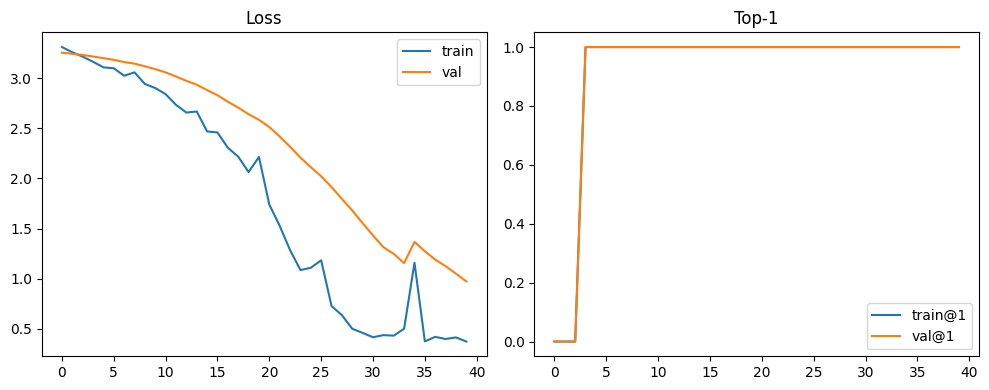

In [46]:
# Plot curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(history['train_loss'], label='train'); plt.plot(history['val_loss'], label='val'); plt.title('Loss'); plt.legend()
plt.subplot(1,2,2); plt.plot(history['train_top1'], label='train@1'); plt.plot(history['val_top1'], label='val@1'); plt.title('Top-1'); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
# Evaluate on test split if present + confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

def eval_loader(loader):
    model.eval()
    all_p, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            all_p.append(logits.argmax(dim=1).cpu().numpy())
            all_y.append(y.cpu().numpy())
    p = np.concatenate(all_p); y = np.concatenate(all_y)
    top1 = (p == y).mean()
    cm = confusion_matrix(y, p, labels=list(range(len(LABELS))))
    return top1, cm

val_top1, val_cm = eval_loader(val_loader)
print('Val top1:', round(float(val_top1), 3))
disp = ConfusionMatrixDisplay(val_cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(7,7)); disp.plot(ax=ax, xticks_rotation=90, cmap='Blues'); plt.tight_layout(); plt.show()

if test_loader is not None:
    test_top1, test_cm = eval_loader(test_loader)
    print('Test top1:', round(float(test_top1), 3))
    disp = ConfusionMatrixDisplay(test_cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(7,7)); disp.plot(ax=ax, xticks_rotation=90, cmap='Blues'); plt.tight_layout(); plt.show()


In [ ]:
# Inference on a single JSON file (set a path you saved)
EXAMPLE_JSON = ''  # e.g., 'data/strokes/test/א/1700000000000.json'
if EXAMPLE_JSON:
    from stroke_recognizer.infer import predict_file
    preds = predict_file(str(SAVE_PATH), EXAMPLE_JSON, n_points=N_POINTS, labels=LABELS, topk=5)
    print(preds)
else:
    print('Set EXAMPLE_JSON to test inference.')
